# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

**Aim:**
1. To understand how to implement neural networks using different deep learning libraries (Keras and TensorFlow).
2. To solve the non-linear XOR problem using a Multi-Layer Perceptron (MLP) and study the effect of hyperparameters such as learning rate, activation functions, number of neurons, and epochs on model performance.

**Student Details:**
- **Register No:** 2547218
- **Course:** Machine Learning Lab


---
## Step 1: Create the Dataset
Define input (X) and output (y) arrays for all 4 XOR combinations.


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Dataset for XOR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("Input X:")
print(X)
print("\nOutput y (XOR):")
print(y)


Input X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output y (XOR):
[[0.]
 [1.]
 [1.]
 [0.]]


---
## Implementation 1: Using Keras (TensorFlow High-Level API)
### Steps 2-5: Build, Compile, Train, and Evaluate the MLP
- Input layer: size 2
- Hidden layer: 4 neurons with ReLU activation
- Output layer: 1 neuron with Sigmoid activation
- Loss: Binary Cross-Entropy
- Optimizer: Adam


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 2. Build the MLP using Keras
keras_model = Sequential([
    Dense(8, input_dim=2, activation='relu', name='hidden_layer'),
    Dense(1, activation='sigmoid', name='output_layer')
])

keras_model.summary()

# 3. Compile the Model
learning_rate = 0.05
optimizer = Adam(learning_rate=learning_rate)
keras_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# 4. Train the Model
print("\nTraining Keras Model...")
history = keras_model.fit(X, y, epochs=200, verbose=0)
print("Training Completed.")

# 5. Evaluate the Model
loss, accuracy = keras_model.evaluate(X, y, verbose=0)
print(f"Keras Model Accuracy: {accuracy * 100:.2f}%")

predictions = keras_model.predict(X)
predictions_binary = (predictions >= 0.5).astype(int)

print("\nPredictions vs Actual:")
for i in range(len(X)):
    print(f"Input: {X[i]} | Actual: {y[i][0]} | Predicted: {predictions_binary[i][0]} (Prob: {predictions[i][0]:.4f})")


C:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

...


Training Keras Model...


Training Completed.
Keras Model Accuracy: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step



Predictions vs Actual:
Input: [0. 0.] | Actual: 0.0 | Predicted: 0 (Prob: 0.0133)
Input: [0. 1.] | Actual: 1.0 | Predicted: 1 (Prob: 0.9993)
Input: [1. 0.] | Actual: 1.0 | Predicted: 1 (Prob: 0.9992)
Input: [1. 1.] | Actual: 0.0 | Predicted: 0 (Prob: 0.0006)


### Plotting Keras Training Curve and Decision Boundary


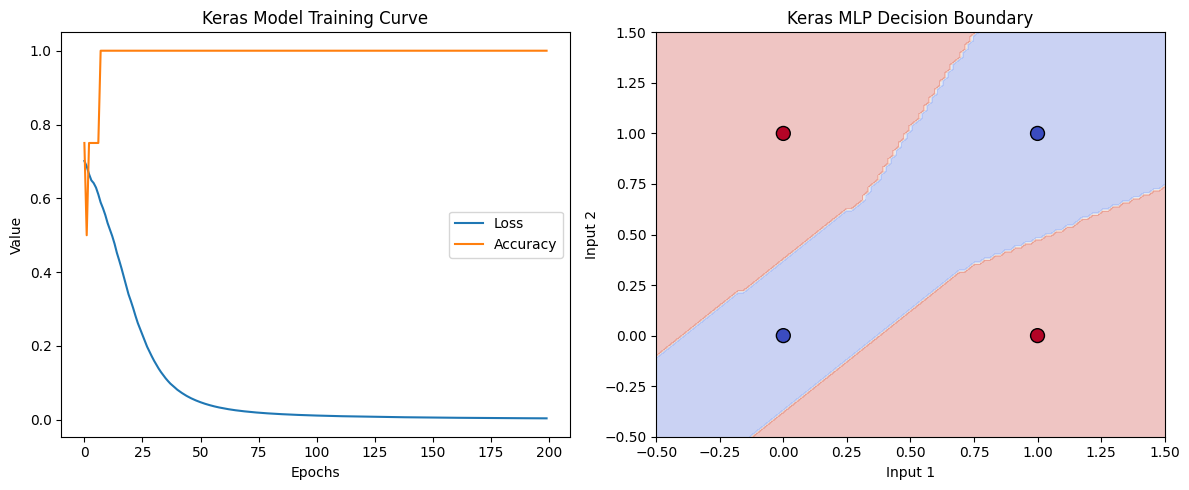

In [3]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # Predict based on model type
    if hasattr(model, 'predict'):
        preds = model.predict(grid, verbose=0)
    else: # For custom TF model
        preds = model(tf.constant(grid, dtype=tf.float32)).numpy()
        
    Z = (preds >= 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=100, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')

plt.figure(figsize=(12, 5))

# Plot Training Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Keras Model Training Curve')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()

# Plot Decision Boundary
plt.subplot(1, 2, 2)
plot_decision_boundary(keras_model, X, y, 'Keras MLP Decision Boundary')
plt.tight_layout()
plt.show()


---
## Implementation 2: Using TensorFlow Low-Level API
### Steps 2-5: Build, Compile, Train, and Evaluate the MLP
Using `tf.Variable`, `tf.GradientTape`, and manual forward/backward passes.


In [4]:
# 2. Build the MLP Structure (Low-Level TF)
# Define weights and biases manually
tf.random.set_seed(42)

# Hidden layer (2 inputs -> 8 neurons)
W1 = tf.Variable(tf.random.normal([2, 8]), dtype=tf.float32)
b1 = tf.Variable(tf.zeros([8]), dtype=tf.float32)

# Output layer (8 neurons -> 1 output)
W2 = tf.Variable(tf.random.normal([8, 1]), dtype=tf.float32)
b2 = tf.Variable(tf.zeros([1]), dtype=tf.float32)

# Forward pass function
def tf_model(X_input):
    hidden_out = tf.nn.relu(tf.matmul(X_input, W1) + b1)
    output = tf.nn.sigmoid(tf.matmul(hidden_out, W2) + b2)
    return output

# 3. Define Loss and Optimizer
# Binary Cross-Entropy loss
def bce_loss(y_true, y_pred):
    epsilon = 1e-7 # to prevent log(0)
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    loss = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    return tf.reduce_mean(loss)

optimizer_tf = tf.keras.optimizers.Adam(learning_rate=0.05)

# 4. Train the Model (Custom Training Loop)
epochs = 200
loss_history_tf = []

print("Training TensorFlow Low-Level Model...")
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = tf_model(X)
        loss = bce_loss(y, y_pred)
        
    # Calculate gradients
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    
    # Update weights
    optimizer_tf.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    
    loss_history_tf.append(loss.numpy())

print("Training Completed.")

# 5. Evaluate the Model
final_preds_tf = tf_model(X).numpy()
preds_binary_tf = (final_preds_tf >= 0.5).astype(int)
acc_tf = np.mean(preds_binary_tf == y)

print(f"TensorFlow Low-Level Model Accuracy: {acc_tf * 100:.2f}%")

print("\nPredictions vs Actual:")
for i in range(len(X)):
    print(f"Input: {X[i]} | Actual: {y[i][0]} | Predicted: {preds_binary_tf[i][0]} (Prob: {final_preds_tf[i][0]:.4f})")


Training TensorFlow Low-Level Model...


Training Completed.
TensorFlow Low-Level Model Accuracy: 100.00%

Predictions vs Actual:
Input: [0. 0.] | Actual: 0.0 | Predicted: 0 (Prob: 0.0084)
Input: [0. 1.] | Actual: 1.0 | Predicted: 1 (Prob: 0.9993)
Input: [1. 0.] | Actual: 1.0 | Predicted: 1 (Prob: 0.9979)
Input: [1. 1.] | Actual: 0.0 | Predicted: 0 (Prob: 0.0007)


### Plotting TensorFlow Low-Level Training Curve and Decision Boundary


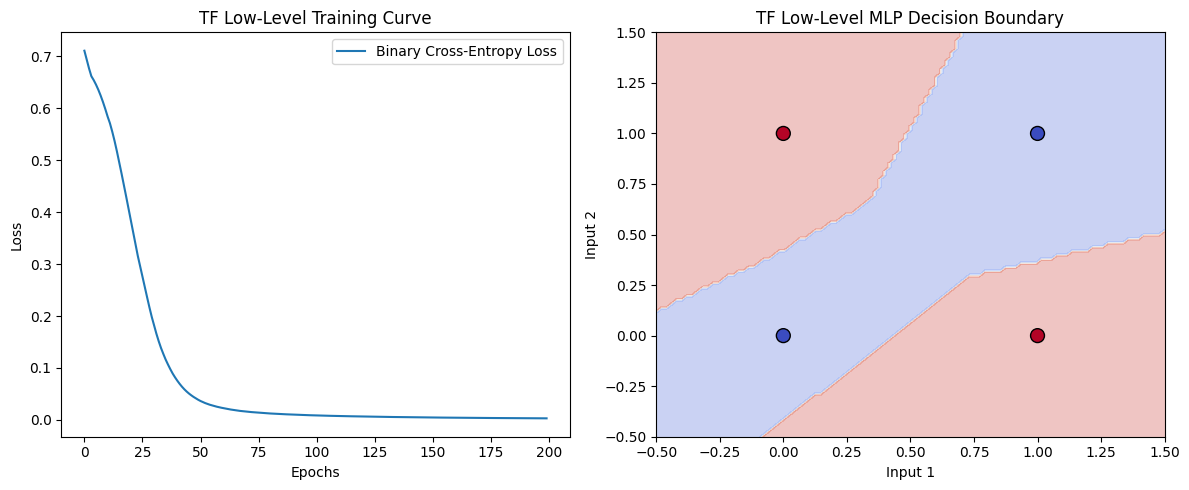

In [5]:
plt.figure(figsize=(12, 5))

# Plot Training Curve
plt.subplot(1, 2, 1)
plt.plot(loss_history_tf, label='Binary Cross-Entropy Loss')
plt.title('TF Low-Level Training Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Decision Boundary
plt.subplot(1, 2, 2)
plot_decision_boundary(tf_model, X, y, 'TF Low-Level MLP Decision Boundary')
plt.tight_layout()
plt.show()


---
## Discussion & Additional Observations

### Comparison of Keras and TF Low-Level
Both implementations converged to successfully solve the non-linear XOR problem. The Keras implementation abstract heavily the forward/backward pass computations through its `fit` function. In contrast, the low-level TensorFlow API required manual setup of the `tf.GradientTape()` to record operations, calculate gradients, and apply them using the optimizer.

### Effect of Hyperparameters
- **Activation Functions:** A non-linear activation (ReLU or Tanh) in the hidden layer is strictly required. Without it, the MLP degenerates into a linear classifier, which fundamentally cannot solve XOR.
- **Number of Neurons:** 2 neurons in the hidden layer is the theoretical minimum required to draw the two distinct boundary lines for XOR. Using 4 or 8 neurons makes the optimization landscape smoother and leads to faster, more robust convergence.
- **Learning Rate:** A very low learning rate (e.g., 0.001) required significantly more epochs (2000+) to converge. Increasing the learning rate (0.05) with Adam allowed convergence in ~200 epochs. However, a learning rate that is too high causes divergence.
- **Epochs:** Given the small dataset, a sufficient number of epochs is crucial to traverse the gradient descent path properly. Too few epochs lead to underfitting.
